In [19]:
import pandas as pd
import duckdb
import os
import seaborn as sns
import matplotlib.pyplot as plt
from lib import dbconnection
# 1. Carichiamo i dati da Postgres
engine = dbconnection.create_db_engine()
df_details = pd.read_sql("SELECT mal_id, genres FROM public.details WHERE genres IS NOT NULL", engine)

# 2. PULIZIA DEI GENERI IN PANDAS (Rimuove [ ] ' e " )
# Questo trasforma "['Action', 'Comedy']" in "Action, Comedy"
df_details['genres'] = df_details['genres'].astype(str).str.replace(r"[\[\]'\" ]", "", regex=True)

# 3. Percorso Parquet
path_ratings = os.path.normpath(os.path.join(os.getcwd(), "..", "..", "..", "cleaned_data", "ratings_cleaned.parquet")).replace('\\', '/')

In [20]:
# 4. QUERY SQL SEMPLICE (Senza Regex complicate)
query_clusters = f"""
    WITH user_genres AS (
        SELECT
            r.username,
            unnest(string_split(d.genres, ',')) as genere
        FROM read_parquet('{path_ratings}') r
        JOIN df_details d ON r.anime_id = d.mal_id
        WHERE r.score >= 7
    ),
    user_top_genre AS (
        SELECT
            username,
            genere,
            COUNT(*) as conteggio
        FROM user_genres
        GROUP BY username, genere
    ),
    ranked_user_genres AS (
        SELECT
            username,
            genere,
            ROW_NUMBER() OVER(PARTITION BY username ORDER BY conteggio DESC) as rnk
        FROM user_top_genre
    )
    SELECT
        genere as Cluster_Gusto,
        COUNT(username) as Numero_Componenti
    FROM ranked_user_genres
    WHERE rnk = 1
    GROUP BY genere
    ORDER BY Numero_Componenti DESC
"""

df_clusters = duckdb.sql(query_clusters).df()

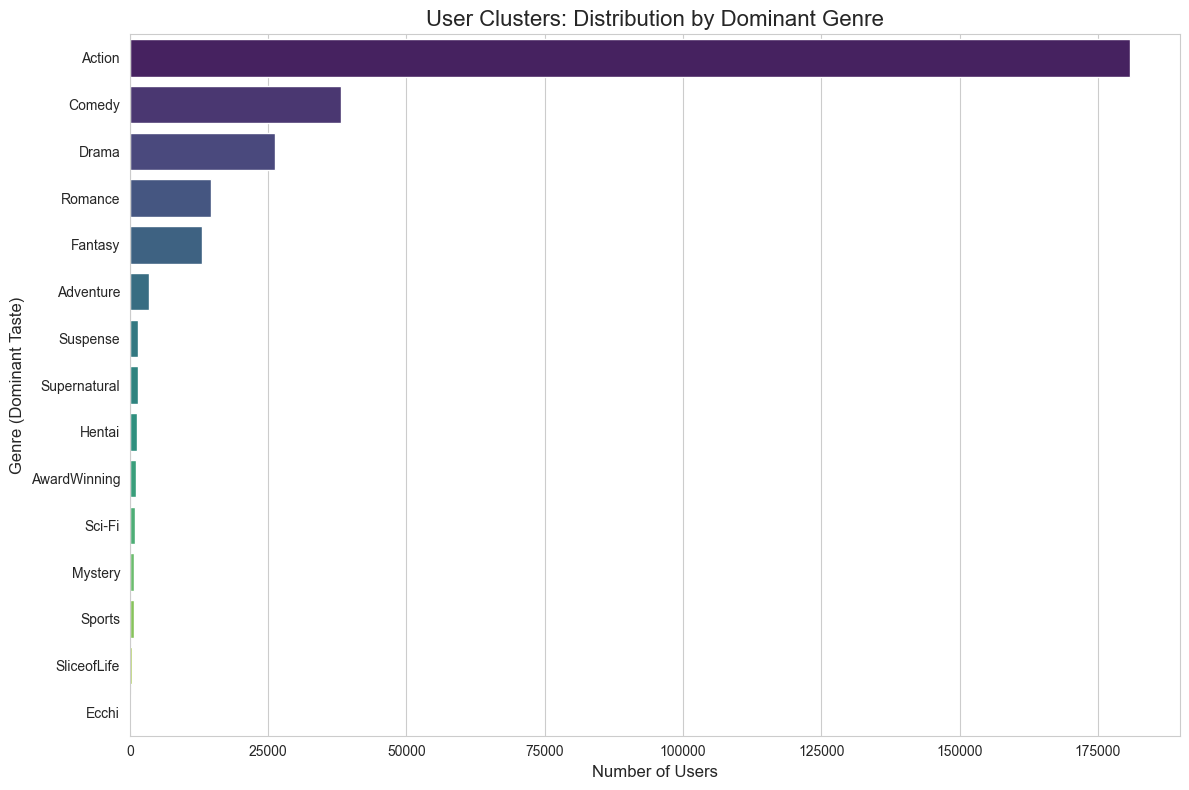

In [21]:
# 5. GRAFICO SENZA WARNING E SENZA PUNTEGGIATURA
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.barplot(
    data=df_clusters.head(15),
    x='Numero_Componenti',
    y='Cluster_Gusto',
    hue='Cluster_Gusto',
    palette='viridis',
    legend=False
)

plt.title('User Clusters: Distribution by Dominant Genre', fontsize=16)
plt.xlabel('Number of Users', fontsize=12)
plt.ylabel('Genre (Dominant Taste)', fontsize=12)

plt.tight_layout()
plt.show()